# 01 — Data Loading and Validation

This notebook is the first of three notebooks in the pairs trading research pipeline. Its scope is limited to data loading, data validation, diagnostics inspection, and basic visualization of the loaded price and volume matrices.

The notebook calls the project’s Python modules rather than duplicating logic inside notebook cells. Specifically, it uses the data loading and validation functions defined in `src/` to fetch historical price and volume data, validate the resulting price and volume matrices, inspect diagnostics, save processed data for downstream notebooks, and plot normalized prices.

This notebook loads adjusted close and adjusted volume data from Tiingo.
The adjusted close matrix is validated by the price validator, and the adjusted
volume matrix is validated by the volume validator. A dollar-volume matrix is
created as adjusted close multiplied by adjusted volume, which will be used for
liquidity-aware pair selection in Notebook 02.

The full project notebook flow is:

1. `01_data_loading_validation.ipynb` — load and validate market data.
2. `02_spread_modeling.ipynb` — compute log prices, hedge model, spread, and z-score.
3. `03_backtest_report.ipynb` — run backtest logic and summarize performance metrics.

This notebook has 8 sections as follows:

 1. Project Setup and Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import json

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import fetch_tiingo_price_matrix
from src.config_loader import (
    load_run_config,
    load_universe_config
)

print(PROJECT_ROOT)

c:\Users\Aditi\Aditi_Workspaces\VSCode\QuantProjects\pairs-trading-ai-tech


2. Load Environment variables

In [2]:
load_dotenv(PROJECT_ROOT / ".env")
api_key = os.getenv("TIINGO_API_KEY")

3. Define tickers and date range. AAPL and MSFT are used as an initial large-cap technology pair for pipeline demonstration. Pair choice is illustrative in v1; later versions can add systematic pair selection using correlation, cointegration, sector grouping, and stability checks.

In [3]:
run_json_file_path = PROJECT_ROOT/"config/run_config.json"
v2_universe_file_path = PROJECT_ROOT/"config/v2_universe.json"

config = load_run_config(run_json_file_path)
v2_univ = load_universe_config(v2_universe_file_path)
    
tickers = v2_univ["tickers"]
start_date = config["date_range"]["start_date"]
end_date = config["date_range"]["end_date"]
price_field = config["data_loader"]["price_field"]
volume_field = config["data_loader"]["volume_field"]
validate = config["data_loader"]["validate"]

print("Tickers:",tickers)
print("Start Date:",start_date)
print("End Date:",end_date)
print("Price Field:",price_field)
print("Volume_field:",volume_field)
print("Validate:",validate)

Tickers: ['MSFT', 'AAPL', 'AMZN', 'GOOGL', 'BRK-B', 'META', 'JNJ', 'JPM', 'V', 'XOM', 'WMT', 'BAC', 'PG', 'PFE', 'UNH', 'VZ', 'T', 'CVX', 'INTC', 'WFC', 'KO', 'CSCO', 'MA', 'HD', 'MRK', 'ORCL', 'BA', 'CMCSA', 'PEP', 'DIS', 'ABBV', 'MCD', 'AMGN', 'ABT', 'PM', 'MDT', 'NFLX', 'NKE', 'CRM', 'IBM', 'UNP', 'TXN', 'HON', 'LLY', 'ACN', 'COST', 'AVGO', 'NVDA', 'TMO', 'BMY']
Start Date: 2019-01-01
End Date: 2025-12-31
Price Field: adjClose
Volume_field: adjVolume
Validate: True


4. Fetch prices using fetch_tiingo_price_matrix()

In [4]:
price_matrix, volume_matrix, loader_diagnostics = fetch_tiingo_price_matrix(tickers,start_date,end_date,api_key=api_key,price_field=price_field,volume_field=volume_field,validate=validate)

5. Inspect price matrix and volume matrix

In [5]:
price_matrix.head()

,MSFT,AAPL,AMZN,GOOGL,BRK-B,META,JNJ,JPM,V,XOM,...,UNP,TXN,HON,LLY,ACN,COST,AVGO,NVDA,TMO,BMY
date,,,,,,,,,,,,,,,,,,,,,
2019-01-02 00:00:00+00:00,94.178105,37.470442,76.9565,52.267823,202.80,134.508492,103.795187,80.783737,126.060237,49.642400,...,116.875749,76.551590,106.363317,104.161277,124.468270,185.005009,20.953041,3.373143,215.052143,39.545433
2019-01-03 00:00:00+00:00,90.713484,33.738109,75.0140,50.820234,191.66,130.602511,102.145838,79.644907,121.517440,48.880205,...,112.549531,72.037113,104.943310,100.924371,120.218695,181.083727,19.089244,3.169348,207.946464,34.341094
2019-01-04 00:00:00+00:00,94.932499,35.178367,78.7695,53.426984,195.20,136.758892,103.860186,82.581049,126.752563,50.682404,...,116.884232,75.295317,108.614350,103.961804,124.893228,186.342221,19.276864,3.372400,217.345562,35.688251
2019-01-07 00:00:00+00:00,95.053574,35.100066,81.4755,53.320435,196.91,136.858029,103.193946,82.638460,129.038187,50.945967,...,117.613751,76.592115,109.219466,104.523955,125.327038,187.028897,19.669460,3.550937,220.276042,36.845132
2019-01-08 00:00:00+00:00,95.742773,35.769181,82.8290,53.788758,196.31,141.299347,105.590782,82.482631,129.739997,51.316379,...,127.877915,76.494855,108.993556,105.485053,128.496513,188.429355,19.511595,3.462535,225.401931,36.525468


In [6]:
price_matrix.tail()

,MSFT,AAPL,AMZN,GOOGL,BRK-B,META,JNJ,JPM,V,XOM,...,UNP,TXN,HON,LLY,ACN,COST,AVGO,NVDA,TMO,BMY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-24 00:00:00+00:00,485.853036,273.298891,232.38,313.684899,501.34,666.371126,205.492701,326.045638,353.690440,117.639285,...,232.610004,175.085964,194.885054,1073.343667,266.068172,869.392993,349.515572,188.384477,577.961029,53.507183
2025-12-26 00:00:00+00:00,485.544412,272.889657,232.52,313.105647,498.30,662.118650,205.344352,324.797597,353.551012,117.530743,...,231.016717,174.838849,195.320485,1074.111067,267.162089,870.878777,351.421730,190.302181,579.577787,53.438722
2025-12-29 00:00:00+00:00,484.937121,273.248985,232.07,313.155583,501.05,657.526773,205.275123,320.677083,353.162603,118.931915,...,232.095402,173.662581,195.043393,1075.087758,267.408466,865.384368,348.687241,187.994943,583.899121,52.920374
2025-12-30 00:00:00+00:00,485.315434,272.570254,232.53,313.445209,503.71,664.773952,204.632278,320.350215,352.176644,119.385816,...,230.640661,173.395697,194.320973,1076.104314,266.087882,863.200565,349.146316,187.315756,582.282364,53.018175
2025-12-31 00:00:00+00:00,481.472573,271.352531,230.82,312.596305,502.65,658.924301,204.671838,319.161605,349.278522,118.744435,...,228.918724,171.487969,193.064161,1071.051433,264.412514,859.899931,345.403859,186.277000,578.290369,52.754111


In [7]:
price_matrix.shape

(1760, 50)

In [8]:
volume_matrix.head()

,MSFT,AAPL,AMZN,GOOGL,BRK-B,META,JNJ,JPM,V,XOM,...,UNP,TXN,HON,LLY,ACN,COST,AVGO,NVDA,TMO,BMY
date,,,,,,,,,,,,,,,,,,,,,
2019-01-02 00:00:00+00:00,35329345,148158948,159662060,31867900,4802100,28146193,7631672,15670850,8788010,16727246,...,3606279,6478750,2924484,4247101,2059602,2143091,30345530,508753600,2725091,8441328
2019-01-03 00:00:00+00:00,42578410,365248780,139511440,41959140,8540600,22717948,8654685,16286426,9428280,13866115,...,5684548,11667534,3378196,4203286,2801252,2877745,68579600,705551440,3125038,80351600
2019-01-04 00:00:00+00:00,44060620,234428280,183651500,46028560,6611200,29002059,8831997,16935205,11065782,16043642,...,5649910,7707593,3802169,5795155,2296417,2761611,54247670,585619320,2865393,47515833
2019-01-07 00:00:00+00:00,35656136,219111056,159864260,47453340,5423000,20089337,8404653,15430712,12928362,10844159,...,4034159,5023940,3124193,7749593,2315636,2226738,53433060,709159200,2931378,26804967
2019-01-08 00:00:00+00:00,31514415,164101256,177628560,35413080,4476800,26263793,9351570,13578777,9243043,11438966,...,10558784,5863487,2796985,3428938,2647835,2366493,36795210,786017160,2876560,16415905


In [9]:
volume_matrix.shape

(1760, 50)

In [10]:
print(price_matrix.index.equals(volume_matrix.index))
print(price_matrix.columns.equals(volume_matrix.columns))

True
True


In [11]:
dollar_volume_matrix = price_matrix * volume_matrix
print(dollar_volume_matrix.head())
print(dollar_volume_matrix.shape)

                                   MSFT          AAPL          AMZN  \
date                                                                  
2019-01-02 00:00:00+00:00  3.327251e+09  5.551581e+09  1.228703e+10   
2019-01-03 00:00:00+00:00  3.862436e+09  1.232280e+10  1.046531e+10   
2019-01-04 00:00:00+00:00  4.182785e+09  8.246804e+09  1.446614e+10   
2019-01-07 00:00:00+00:00  3.389243e+09  7.690813e+09  1.302502e+10   
2019-01-08 00:00:00+00:00  3.017277e+09  5.869768e+09  1.471280e+10   

                                  GOOGL         BRK-B          META  \
date                                                                  
2019-01-02 00:00:00+00:00  1.665666e+09  9.738659e+08  3.785902e+09   
2019-01-03 00:00:00+00:00  2.132373e+09  1.636891e+09  2.967021e+09   
2019-01-04 00:00:00+00:00  2.459167e+09  1.290506e+09  3.966289e+09   
2019-01-07 00:00:00+00:00  2.530233e+09  1.067843e+09  2.749387e+09   
2019-01-08 00:00:00+00:00  1.904826e+09  8.788406e+08  3.711057e+09   

    

6. Inspect loader diagnostics

In [12]:
print(loader_diagnostics.keys())

dict_keys(['data_source', 'tickers_requested', 'start_date', 'end_date', 'price_field', 'volume_field', 'data_loader_checks_passed', 'ticker_loader_diagnostics', 'price_matrix_summary', 'volume_matrix_summary', 'validation_was_run', 'price_validation_diagnostics', 'volume_validation_diagnostics'])


In [13]:
print("Data Loader Checks:-",loader_diagnostics['data_loader_checks_passed'])
print("Price Matrix Statistics:-",loader_diagnostics['price_matrix_summary'])
print("Price Matrix Validation:-",loader_diagnostics['price_validation_diagnostics'])
print("Volume Matrix Statistics:-",loader_diagnostics['volume_matrix_summary'])
print("Volume Matrix Validation:-",loader_diagnostics['volume_validation_diagnostics'])

Data Loader Checks:- ['API key check passed.', 'Tickers list check passed.', 'Tickers type check passed.', 'Each ticker is a string check passed.', 'Each ticker is not an empty string check passed.', 'Start date and end date presence check passed.', 'Start date and end date are convertible.', 'Start date is less than end date.', 'Validate parameter type check passed.', 'Price matrix created.', 'Price matrix sorted by date.', 'Volume matrix created.', 'Volume matrix sorted by date.', 'Price matrix validation applied.', 'Volume matrix validation applied.']
Price Matrix Statistics:- {'num_observations': 1760, 'num_assets': 50, 'start_date': Timestamp('2019-01-02 00:00:00+0000', tz='UTC'), 'end_date': Timestamp('2025-12-31 00:00:00+0000', tz='UTC'), 'asset_list': ['MSFT', 'AAPL', 'AMZN', 'GOOGL', 'BRK-B', 'META', 'JNJ', 'JPM', 'V', 'XOM', 'WMT', 'BAC', 'PG', 'PFE', 'UNH', 'VZ', 'T', 'CVX', 'INTC', 'WFC', 'KO', 'CSCO', 'MA', 'HD', 'MRK', 'ORCL', 'BA', 'CMCSA', 'PEP', 'DIS', 'ABBV', 'MCD', '

In [14]:
print("Ticker Diagnostics:-",pd.DataFrame(loader_diagnostics['ticker_loader_diagnostics']))

Ticker Diagnostics:-    ticker  tiingo_request_successful  data_not_empty  date_column_present  \
0    MSFT                       True            True                 True   
1    AAPL                       True            True                 True   
2    AMZN                       True            True                 True   
3   GOOGL                       True            True                 True   
4   BRK-B                       True            True                 True   
5    META                       True            True                 True   
6     JNJ                       True            True                 True   
7     JPM                       True            True                 True   
8       V                       True            True                 True   
9     XOM                       True            True                 True   
10    WMT                       True            True                 True   
11    BAC                       True            True   

7. Save price_matrix to data/processed

In [15]:
#Define filepath
price_file_path = PROJECT_ROOT/f"data/processed/price_matrix_v2_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"
volume_file_path = PROJECT_ROOT/f"data/processed/volume_matrix_v2_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"
dollar_matrix_file_path = PROJECT_ROOT/f"data/processed/dollar_volume_matrix_v2_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"

#Ensure that the directory exists
os.makedirs(os.path.dirname(price_file_path), exist_ok=True)
os.makedirs(os.path.dirname(volume_file_path), exist_ok=True)
os.makedirs(os.path.dirname(dollar_matrix_file_path), exist_ok=True)

#Save the DataFrame
price_matrix.to_csv(price_file_path, index=True, encoding='utf-8')
volume_matrix.to_csv(volume_file_path, index=True, encoding='utf-8')
dollar_volume_matrix.to_csv(dollar_matrix_file_path, index=True, encoding='utf-8')

8. Plot normalized prices.

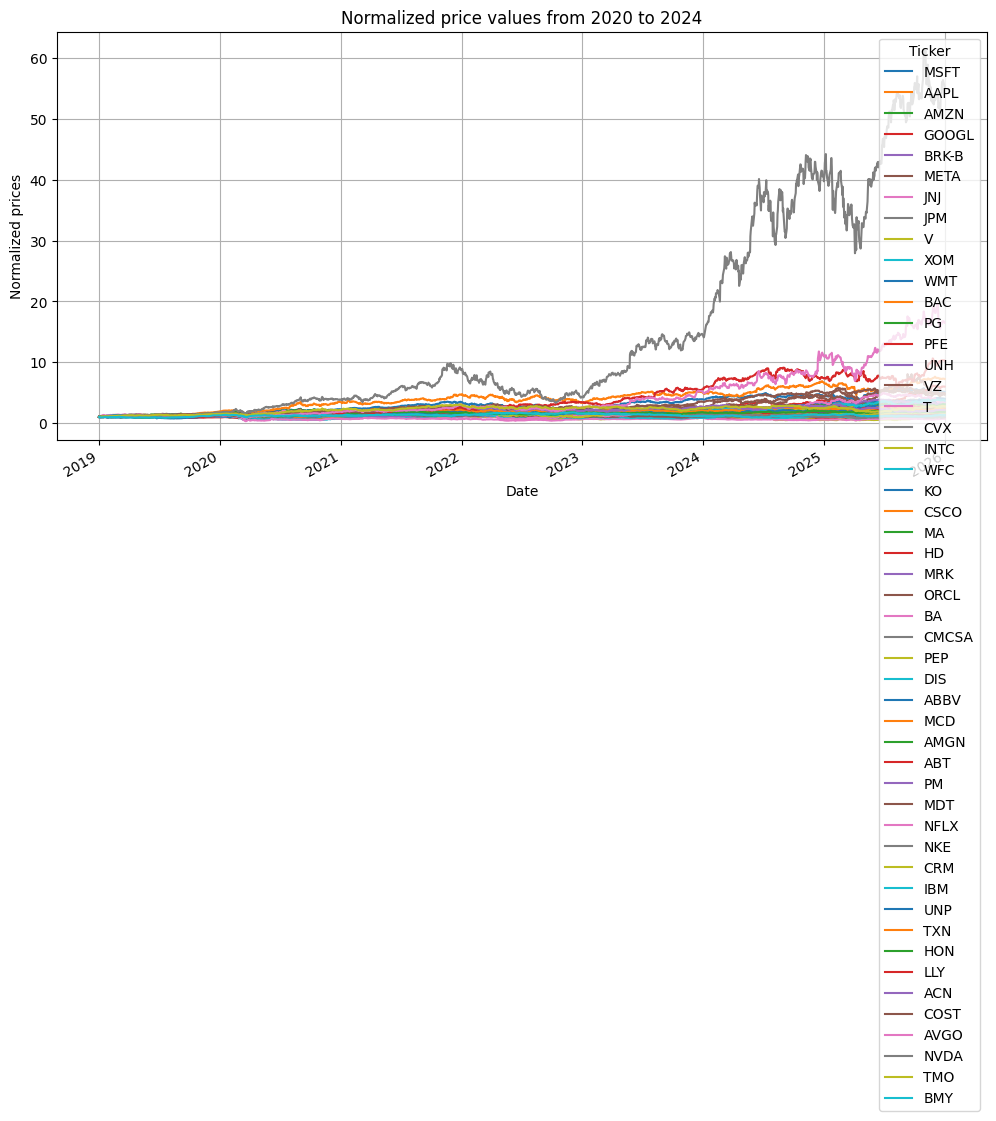

In [16]:
normalized_prices = price_matrix/price_matrix.iloc[0]
normalized_prices.plot(figsize=(12,6))
plt.title('Normalized price values from 2020 to 2024')
plt.xlabel('Date')
plt.ylabel('Normalized prices')
plt.legend(title="Ticker")
plt.grid(True)
plt.show()


The notebook is intentionally kept thin: core logic is implemented in `src/data_loader.py` and `src/data_validator.py`, while this notebook demonstrates usage and inspects outputs.